# Hello SAFIRE
---

<font size="5"><b>Goal:</b>
At the end of this tutorial, you will know how to run an AFQMC calculation using SAFIRE and extract the AFQMC energy from the output
given all necessary inputs.
</font>

## What you will learn

---

<font size="4">

1. what are the inputs and outputs of SAFIRE.
2. how to invoke the SAFIRE executable from the command line in serial, using MPI, and using GPU(s)
3. how to extract the AFQMC energy from the outputs of SAFIRE using afqmctools
4. how to use the tutorial helper functions to perform 2 and 3 from within an interactive Python notebook

</font>

&nbsp;




<font size="5"><b>
Inputs and outputs of SAFIRE.
</b>
</font>

---

<font size="4">

The purpose of this tutorial is to run a first AFQMC calculation without going into low-level details.

<!--
AFQMC is formulated in terms of a generic second quantized Hamiltonian and trial wavefunction.
In order to take advantage of this flexibility, AuxiliaryFields accepts a generic
second quantized Hamiltonian and wavefunction, saved in HDF5 files, as input along with
AFQMC algorithmic parameters in a json-based input file.
-->

Below is a schematic of the inputs and outputs of SAFIRE.

&nbsp;

<!---
<div>
<img src="./figs/inputs_and_outputs_all.png" width="800"/>
</div>
-->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/inputs_and_outputs_all.png" width="800">
</div>



&nbsp;
&nbsp;


We will learn more about the details of all of these files in future tutorials. For this tutorial, pregenerated input files are provided in the "files" directory relative to the directory of this tutorial.



&nbsp;

<font size="5">
<b>The Inputs
</b>
</font>


---
To perform a calculation, SAFIRE requires a Hamiltonian and a trial wave function. Both are provided as inputs using the files "hamil.h5" and "wfn.h5", respectively. The file "input.json" references these two files and provides further information about how the simulation should be run.

&nbsp;

<font size="4">
<b> Hamiltonian file : "hamil.h5"
</b>
</font>

---

&nbsp;

<!--
<div>
<img src="./figs/inputs_and_outputs_hamil.png" width="800"/>
</div>
-->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/inputs_and_outputs_hamil.png" width="800">
</div>



&nbsp;

This HDF5 file contains the second-quantized Hamiltonian $\hat{H}$.

For this tutorial, we have supplied an HDF5 file containing the Born-Oppenheimer
Hamiltonian for Si in its primtive cell at equilibrium
in "hamil.h5".

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/solids/Si_primitive.png" width="600">
</div>


&nbsp;
&nbsp;

For technical details on the Hamiltonian HDF5 format, see [the User Guide](https://users.flatironinstitute.org/~beskridge/auxiliary_fields/afqmc.html#dense-cholesky).

&nbsp;
&nbsp;
&nbsp;

<font size="4">
<b> Wavefunction file : "wfn.h5"
</b>
</font>

---

&nbsp;

<!--
<div>
<img src="./figs/inputs_and_outputs_wfn.png" width="800"/>
</div>
-->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/inputs_and_outputs_wfn.png" width="800">
</div>

&nbsp;

This HDF5 file contains the trial wavefunction, $| \Psi_T \rangle$.


For this tutorial, we have supplied an HDF5 file containing the RHF
ground state as the trial wavefunction.

$$
| \Psi_T \rangle = | \Phi_\mathrm{RHF} \rangle
$$

For technical details on the wavefunction HDF5 format, see [the User Guide](https://users.flatironinstitute.org/~beskridge/auxiliary_fields/afqmc.html#wavefunction-file-formats).

&nbsp;
&nbsp;

<font size="4">
<b> Input file (json format) : "input.json"
</b>
</font>

---

&nbsp;

<!--
<div>
<img src="./figs/inputs_and_outputs_json.png" width="800"/>
</div>
-->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/inputs_and_outputs_json.png" width="800">
</div>


&nbsp;

The JSON input file sets AFQMC run parameters and references the locations of the Hamiltonian and trial wavefunction files. It is organized into a hierarchy of input blocks which each control specific
details of the calculation. Understanding the details of the input file is the goal of the [next tutorial](../02_input_file/input_file.ipynb).

**For now, we focus on the `wavefunction` and `hamiltonian` blocks.**

The `wavefunction` input block is used to tell AuxiliaryFields where to find the HDF5 file containing the trial wavefunction.
Similarly, the `hamiltonian` input block is used to tell AuxiliaryFields where to find the HDF5 file containing the Hamiltonian.  

The sample json file that we have provided is reproduced here.

```json
{
"afqmc": {
  "project": {
    "id": "qmc",
    "series": 0
  },
  "execute": {
    "walker_set": {
      "walker_type": "CLOSED"
    },
    "wavefunction": {
      "filename": "files/wfn.h5"
    },
    "hamiltonian": {
      "filename": "files/hamil.h5"
    },
    "timestep": 0.01,
    "steps": 10000,
    "n_walkers_per_mpi_task": 200,
    "seed": 42
  }
}
}
```
  
Notice that the `wavefunction` and `hamiltonian` input blocks point to the HDF5 file where we have saved the RHF ground
state and second-quantized Hamiltonian, respectively.



&nbsp;
&nbsp;
&nbsp;

<font size="5">
<b>The Outputs
</b>
</font>


---
Now that we have seen the inputs of AuxiliaryFields, we will move on to the outputs.

&nbsp;
&nbsp;

<font size="4">
<b> stdout
</b>
</font>

---

AuxiliaryFields prints information about the setup of the AFQMC calculation to stdout along with timing information at the end.

We will see the output from AuxiliaryFields throughout the tutorials. Here is a sample header which is printed at the beginning of
the output.

&nbsp;

```log

███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
app git branch: fix_compiler_warnings
app git commit: 83a5e18c30fe824a77185cdb5df6e4dba2918f5c
 AFQMCFactory Project settings:
    -- mixed_precision: false
    -- ncores (local) : 1
    -- n_groups       : 1
    -- id             : qmc
    -- series         : 0
    -- MPI tasks/node : 1
    -- MPI nodes      : 1
    -- MPI tasks      : 1


```


&nbsp;

You can see git information from when AuxiliaryFields was compiled.
You can also see MPI / parallelization information.
We will explore the output further in later tutorials.

&nbsp;
&nbsp;
&nbsp;

<font size="4">
<b> scalar data file : [id].s[series].scalar.dat
</b>
</font>

---

&nbsp;

<!--
<div>
<img src="./figs/inputs_and_outputs_scalar.png" width="800"/>
</div>
-->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/inputs_and_outputs_scalar.png" width="800">
</div>



&nbsp;

A text-based file containing stochastic samples of scalar data, such as the energy.

This file is not meant to be read directly by the user.
Instead, afqmctools provides tools to extract information from this file.
**We will learn how to extract the AFQMC energy from this file later in this tutorial.**

The name of this file is derived from the `id` (string) and `series` (integer) parameters set in the json input file. Setting these parameters allows running multiple AFQMC calculations in a single directory without output file collisions.

&nbsp;
&nbsp;
&nbsp;

<font size="4">
<b> observables output HDF5 file : [id].s[series].stat.h5
</b>
</font>

---

&nbsp;

<!--
<div>
<img src="./figs/inputs_and_outputs_hdf5.png" width="800"/>
</div>
-->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/01_hello_auxiliary_fields/inputs_and_outputs_hdf5.png" width="800">
</div>




&nbsp;

An HDF5 file where stochastic samples of non-scalar data, such as the one-body reduced density matrix, are printed by AuxiliaryFields
when requested.

Similar to the `[id].s[series].scalar.dat` file, this file is not meant to be read directly by a user.
Instead, afqmctools provides tools to extract data from this file for you.
You will learn more about this in the [Estimators and post-processing tutorial](../04_using_estimators/04_using_estimators.ipynb).

&nbsp;
&nbsp;
&nbsp;
</font>




## Running SAFIRE

---

<font size="4">

Now that we have learned what the inputs and outputs of SAFIRE are,
we are ready to learn how to run the SAFIRE executable given the inputs.

&nbsp;

### Running SAFIRE in serial
---

AuxiliaryFields can be invoked from the command line as
</font>

```bash
    $ /path/to/SAFIRE/build/bin/safire input.json
```
<font size="4">

where `input.json` is the json input file.
The input file can have an arbitrary name, but must end with `.json`.
When you run the above, an AFQMC calculation will be performed based on the contents of input.json,
using the Hamiltonian and trial wavefunction specified there.

&nbsp;

**For brevity, we will abreviate `/path/to/SAFIRE/build/bin/safire` as `safire` in this tutorial**.
There are many standard ways to make `safire` accessible from the command line in this way.

&nbsp;

You can see the possible command line options for SAFIRE by using the `-h`/`--help` switch.
</font>

&nbsp;

```bash
    $ safire --help

SAFIRE
Usage:
  /path/to/SAFIRE/build/bin/safire [OPTION...] [optional args]

  -h, --help           print help message
  -v, --version        print version message
      --verbosity arg  0, 1, 2, ...: higher means more (default: 2)
      --debug arg      0, 1, 2, ...: higher means more (default: 0)
      --filenames arg  input filenames
```
<font size="4">

&nbsp;


### Exercise: Try Running SAFIRE.

---

<font size="4">

Run SAFIRE with the provided input files.
You may use either the code block below, or run SAFIRE in a terminal
as described previously.
In either case, you can find the json input file here

```bash
    /path/to/SAFIRE/tutorials/molecules/files/input.json
```

&nbsp;

where `/path/to/AuxiliaryFields` should be replaced with the path where
you have installed AuxiliaryFields.

**The provided json input file assumes that you are running AuxiliaryFields from
`/path/to/AuxiliaryFields/tutorials/01_hello_auxiliary_fields/`**

After running with the default parameters, try changing the verbosity level to
see what changes.

<div class="alert alert-block alert-info">
<b>Note:</b>
    in a jupyter notebook, the `!` symbol will run commands in
    a shell instead of in Python.
</div>

</font>


In [ ]:
%%time
!safire files/input.json

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: ee49a5e69208e2afc03aab970572b9e79759e543
app git commit date: Fri Nov 7 13:27:02 2025 -0500
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series         : 0 
    -- MPI tasks/node : 1 
    -

### Post-excercise

---

You should see the following a the top of the
output after running AuxiliaryFields.

```log
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: ee49a5e69208e2afc03aab970572b9e79759e543
app git commit date: Fri Nov 7 13:27:02 2025 -0500
 AFQMCFactory Project settings:
    -- mixed_precision: false
    -- ncores (local) : 1
    -- n_groups       : 1
    -- id             : qmc
    -- series         : 0
    -- MPI tasks/node : 1
    -- MPI nodes      : 1
    -- MPI tasks      : 1

```

&nbsp;


Congratulations, you have now run an AFQMC calculation using AuxiliaryFields!
In the directory that you ran this notebook from, you should see a file called
`qmc.s000.scalar.dat`.
We will return to how to use the tools in `afqmctools` to extract the AFQMC energy later in this tutorial.


&nbsp;



## Running SAFIRE in parallel

---

&nbsp;

### Using MPI

---

SAFIRE can be run with MPI in the usual ways.
For example, using mpirun, we could run SAFIRE with 64 MPI tasks as

```bash
    $ mpirun -np 64 safire --filenames input.json
```

It is important to note that the number of walkers is specified in the input file
as `n_walkers_per_mpi_task`.
So, the total number of walkers using the sample input file above and 64 MPI tasks
would be

$$
N_\mathrm{walkers} = n_\mathrm{walkers\_per\_mpi} \times n_\mathrm{mpi\_task} = 200 \times 64 = 12800.
$$

For the sample inputs, this is significantly more walkers than necessary,
and for calculations that run on a CPU only build of SAFIRE,
`n_walkers_per_mpi_task` will typically be on the order of 10-50.

&nbsp;

### GPU Builds

---

To run on GPUs, you must compile SAFIRE for the GPU.
See the [documentation](https://users.flatironinstitute.org/~beskridge/auxiliary_fields/getting_started.html#gpu-accelerated-build-at-ccq) for instructions on compiling for GPU.

On GPU builds of SAFIRE, the calculation is more efficient when
the GPU is saturated.
The specific number of walkers needed to achieve this depends on how large the system is and how much memory is available on the GPUs.
For small systems, this could mean using on the order of 1000 walkers or more per task.
For very large systems, this may mean on the order of 10 walkers per MPI task.

&nbsp;


## Basic post-processing

---

Now that we've learned how to invoke the SAFIRE executable from the command line in serial, using MPI, and using GPU(s),
we are ready to learn how to extract the AFQMC energy from the outputs using afqmctools.

We previously ran SAFIRE on the Hamiltonian of the STO-3G basis hydrogen dimer
with bondlength $\delta_{H-H} = 1.4 a_0$.
This generated a scalar data file, `qmc.s000.scalar.dat`, which contains
the scalar data that was accumulated during the AFQMC calculation, including the AFQMC energy.

afqmctools provides the `scalar_stats` CLI tool to extract data from the scalar data file.
If you followed the official installation instructions for `afqmctools`, you
should be able to run `$ scalar_stats` from within whichever Python environment you
installed afqmctools in.

By default, `scalar_stats` will compute the average AFQMC energy and the stochastic uncertainty of the
energy based on the samples in the `*.scalar.dat` file.
Below is an example of using `scalar_stats` where we have set the "x axis" to (AFQMC projection) time,
and the equilibration time to 2.0 inverse energy units.

```bash
$ scalar_stats qmc.s000.scalar.dat -s time -e 2.0

====== [analyze_scalar_data Settings] ======

[+] fname            = qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = time           
[+] nequil           = 2.0             
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] ndiscard         = None            
[+] list             = False           
[+] trace            = False           
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] verbose          = True            
[+] autocorr         = None            
[+] savefig          = None            
[+] dump_avail_columns = False           

AFQMC Energy    -1.135742 +/-   0.000286 7.87  2.0/100.0
```


You can also view the AFQMC energy as a function of the projection time (sometimes referred to as the "equilibration curve") by
adding the `-t` option to plot the data trace.

Running

```bash
$ scalar_stats qmc.s000.scalar.dat -s time -e 2.0 -t
```

will generate the plot,

<!--
<div>
<img src="./figs/HelloAuxyFields_equil.png" width="600"/>
</div>
-->

<div>
<img src="https://users.flatironinstitute.org/~beskridge/tutorial_figs/6784ee4ea455921958ac327234b91ab07702736ab22fa2df804e8dccbc36a404/solids/Equil_Si_prim_01_hello_safire.png" width="800">
</div>


One should check the equlibration curve to ensure that the the equilibration
time, `-s time -e 2.0`, is large enough to discard the samples where AFQMC is not sampling from the target many-body wavefunction yet.
On the other hand, the equilibration length should not be so large that it discards equilibrated samples.

<div class="alert alert-block alert-info">
<b>Note:</b>
    Using the `-t` option to plot the trace will only work when running locally;
    you can use the `--savefig [SAVEFIG]` option to save the figure as an image
    in the file "SAVEFIG". The file type is detected from the file extension in
    the name. *.png is generally recommended.
</div>


&nbsp;

### Exercise: Try Running scalar_stats

---

<font size="4">

Use the code block below to run scalar_stats on the data that we generated
in the last exercise.
You should get an AFQMC energy of `-1.135742 +/-   0.000286`
if you did not change any settings.

Now, try to changing the equilbration length such that only un-equilibrated samples
are discarded.

</font>

In [ ]:
%%time
!scalar_stats qmc.s000.scalar.dat -s time -e 2.0 -t



====== [analyze_scalar_data Settings] ======

[+] fname            = qmc.s000.scalar.dat
[+] mark_header      = #               
[+] series_column    = time            
[+] nequil           = 2.0             
[+] estimate_equil   = False           
[+] column           = LocalEnergy     
[+] reblock          = 1               
[+] ndiscard         = None            
[+] list             = False           
[+] trace            = False           
[+] append           = None            
[+] dump             = False           
[+] dump_fname       = trace.dat       
[+] verbose          = True            
[+] autocorr         = None            
[+] savefig          = None            
[+] dump_avail_columns = False           

AFQMC Energy    -0.731008 +/-   0.002292 18.39  2.0/100.0
CPU times: user 53 ms, sys: 16.8 ms, total: 69.8 ms
Wall time: 3.59 s


&nbsp;

## Post Exercise

---

If you play around with the equilbration length, you will see that, for very small equilibration length,
the predicted energy will be incorrect.
This is due to the inclusion of un-equilibrated samples in the average.
On the other hand, the average energy should be stable if you use too large of a value for the equilibration length.

&nbsp;

## Some Tutorial Helper Python Functions

---

Now that we have learned how to extract the AFQMC energy from the outputs of AuxiliaryFields using afqmctools,
we will introduce several tutorial helper functions to invoke AuxiliaryFields and extract the AFQMC energy
from within an interactive Python notebook.

For convenience, we provide two helper functions in the `tutorials_utils` Python package.

1. The `run_afqmc()` function runs the AuxiliaryFields executable in one of the several ways that
we described previously, depending on the `run_mode` parameter.
2. the `get_scratch_dir()` function, will generate a scratch directory and return a Path pointing to the scratch directory.

Together, these functions make it possible to complete the tutorials without leaving the interactive Python notebooks.
We explain each function below.

&nbsp;


### get_scratch_dir()

---

`get_scratch_dir()` will return a reference to the Path of a scratch directory that you get to set.
By default, it will create the directory if it does not already exits.
You can either specify the full path to the scratch directory as,

```python
    from tutorial_utils import get_scratch_dir
    scratch_dir = get_scratch_dir('/path/to/my/scratch/hello_safire')
```

or, you can pass a scratch root directory and scratch directory name as

```python
    from tutorial_utils import get_scratch_dir
    scratch_dir = get_scratch_dir('hello_safire', root_dir='/path/to/my/scratch/')
```

You can tell `get_scratch_dir()` to not attempt to create the directory with

```python
    from tutorial_utils import get_scratch_dir
    scratch_dir = get_scratch_dir('/path/to/my/scratch/hello_safire',create=False)
```

&nbsp;





### The run AFQMC convenience function

---

`run_afqmc(input_file=input_file, np=np)` runs the SAFIRE executable as

```bash
    $ mpirun -np [np] safire --filenames [input_file]
```

<div class="alert alert-block alert-warning">
<b>CAUTION:</b>
    The `AFQMC_EXEC` environment variable must be set to the path to the SAFIRE executable
    in order to use `run_afqmc()`.
</div>

Here is a typical example of using `run_afqmc()`.

```python
    from tutorial_utils import run_afqmc, get_scratch_dir

    scratch_dir = get_scratch_dir('/path/to/my/scratch/hello_safire')
    
    run_afqmc(
        run_dir=scratch_dir,                # directory to run SAFIRE in - output files will be there
        input_file="/path/to/inputfile/input.json",
        np=12,                              # number of MPI tasks
        output_file=None                    # optionally direct output to file; if None,
    )                                       # then output will be captured in the jupyter notebook.
```

Where the `np` parameter is forwarded directly to `-np [np]` and
`input_file` is passed to `safire --filenames [input_file]`.

<div class="alert alert-block alert-info">
<b>Note:</b>
    There is no difference between running SAFIRE via `run_afqmc()` or
    directly in the command line other than convenience.
</div>

&nbsp;


### (afqmctools) the analyze scalar data function
---

The same functionality as `$ scalar_stats`, from `afqmctools`, can
be accessed directly in a Python script via the `analyze_scalar_data()` function.
This is a standard component of `afqmctools`, and not just a part of these tutorials.

For convenience, we will favor the use of `analyze_scalar_data()` within interactive Python
notebooks; however, this invokes exactly the same code as using `$ scalar_stats` from
the CLI.
`scalar_stats` can generate plots of the data, both from the CLI and from within Python.
We will make use of this feature during the tutorials to visualize results.

&nbsp;


### Exercise: Run the full sample calculation using the convenience wrappers.
---


Use the code block below to run the entire calculation again.

Just as before, at the end, you should get an AFQMC energy of `-1.135742 +/-   0.000286`
if you did not change any settings.

<div class="alert alert-block alert-info">
<b>Note:</b>
    The python `Path` class from `pathlib`, which is a part of the standard cPython distribution,
    greatly simplifies the process of specifying, and creating directories. We recommend using it
    in these tutorials. See the code block below.
</div>



Running AFQMC locally with 16 mpi tasks
--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on ccqlin053 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------
███████╗ █████╗ ███████╗██╗██████╗ ███████╗
██╔════╝██╔══██╗██╔════╝██║██╔══██╗██╔════╝
███████╗███████║█████╗  ██║██████╔╝█████╗  
╚════██║██╔══██║██╔══╝  ██║██╔══██╗██╔══╝  
███████║██║  ██║██║     ██║██║  ██║███████╗
╚══════╝╚═╝  ╚═╝╚═╝     ╚═╝╚═╝  ╚═╝╚══════╝


AF App version: 1.0.0
This build has the following enabled:
 - MKL:  1
 - CUDA: 0
 - HIP:  0
app git branch: develop
app git commit: ee49a5e69208e2afc03aab970572b9e79759e543
app git commit date: Fri Nov 7 13:27:02 2025 -0500
 AFQMCFactory Project settings: 
    -- mixed_precision: false 
    -- ncores (local) : 1 
    -- n_groups       : 1 
    -- id             : qmc 
    -- series      

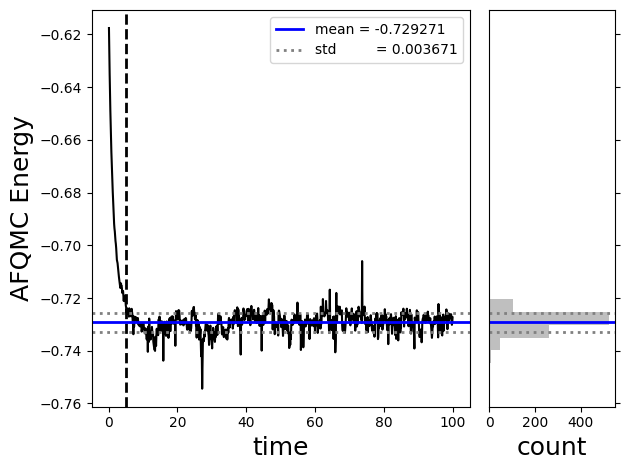

CPU times: user 7.85 s, sys: 505 ms, total: 8.36 s
Wall time: 2min 8s


In [ ]:
%%time
from pathlib import Path
import shutil

import numpy as np

from afqmctools.hamiltonian.mol import write_hamiltonian_generic
from afqmctools.wavefunction.mol import write_wfn
from afqmctools.inputs.from_hdf import write_json
from tutorial_utils import run_afqmc, get_scratch_dir
from stats.scalar_dat import analyze_scalar_data

# For you TODO: set a scratch directory for the files that will be generated
home = Path.home()
scratch_dir = get_scratch_dir("hello_safire",home / ".scratch")

# copy the provided files
files_dir = scratch_dir / "files"
files_dir.mkdir(exist_ok=True)
shutil.copy("files/input.json", scratch_dir / "files" )
shutil.copy("files/wfn.h5", scratch_dir / "files" )
shutil.copy("files/hamil.h5", scratch_dir / "files")

run_afqmc(
    run_dir=scratch_dir,
    input_file="files/input.json",   # the location of the sample input file.
    np=16,                                         # to run in serial just as before!
    output_file=None
)

# post process!
_ = analyze_scalar_data(dict(
    fname = scratch_dir/"qmc.s000.scalar.dat",
    series_column = "time",
    nequil = 5,
    trace = True
))

&nbsp;

## Summary

---


<font size="4">

In this tutorial we have learned,

1. what are the inputs and outputs of SAFIRE.
2. how to invoke the SAFIRE executable from the command line in serial, using MPI, and using GPU(s)
3. how to extract the AFQMC energy from the outputs of SAFIRE using afqmctools
4. how to use the tutorial helper functions to perform 2 and 3 from within an interactive Python notebook

</font>

---

<font size="6">

Next, we will take a more detailed look at the input file in [Understanding the input file](https://colab.research.google.com/drive/1rWeqD-DVQNMN8ILqelEZ56OURmCYpozp#scrollTo=17b6510b).

</font>
